# 01 棕榈油 + ONI + 降水 数据探查 (EDA)

> 第一周交付物 6 (R4 / Day 6) 验收件之一：能从头跑到尾、无报错的数据探查 notebook。

**单品种聚焦**：本项目锁定棕榈油 (Palm Oil, CPO=F)，配合 NOAA ONI 与马来西亚降水做共同建模特征。

**本 notebook 做什么**：
1. 读取三份核心数据：棕榈油日线、ONI 长表、马来西亚月度降水（区域均值）
2. 打印结构、描述性统计 (describe)、缺失值检查
3. 三张走势图（棕榈油 / ONI / PRCP）用于肉眼检异常

数据全部由 `backend/app/core/data.py` 统一定位，与 FastAPI 共用同一份数据加载层。

In [1]:
import os, sys
# notebook 位于 code/notebooks/ ，项目根 ONI project/ 在两层之上
HERE = os.getcwd()
if os.path.basename(HERE) == 'notebooks':
    PROJECT_ROOT = os.path.dirname(os.path.dirname(HERE))   # code/notebooks -> code -> ONI project
else:
    PROJECT_ROOT = HERE
BACKEND = os.path.join(PROJECT_ROOT, 'code', 'backend')
if BACKEND not in sys.path:
    sys.path.insert(0, BACKEND)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from app.core.data import (
    load_palm_oil,
    load_prcp_oni_merged,
    PALM_CSV,
    PRCP_ONI_CSV,
    ONI_LONG_CSV,
    PRCP_REGIONAL_CSV,
)

print('numpy   :', np.__version__)
print('pandas  :', pd.__version__)
print('PROJECT_ROOT :', PROJECT_ROOT)
print()
for label, path in [
    ('PALM_CSV     ', PALM_CSV),
    ('PRCP_ONI_CSV ', PRCP_ONI_CSV),
    ('ONI_LONG_CSV ', ONI_LONG_CSV),
    ('PRCP_REGIONAL', PRCP_REGIONAL_CSV),
]:
    print(f'{label} exists={os.path.exists(path)}  -> {path}')

numpy   : 2.0.2
pandas  : 2.3.3
PROJECT_ROOT : /Users/sunnyqqqqqqqqq/ONI project

PALM_CSV      exists=True  -> /Users/sunnyqqqqqqqqq/ONI project/data/raw/product/CPO_F_daily_yahoo.csv
PRCP_ONI_CSV  exists=True  -> /Users/sunnyqqqqqqqqq/ONI project/data/processed/meteo/kuala_lumpur_malaysia_prcp_noaa_nino34_pacific_oni_merged.csv
ONI_LONG_CSV  exists=True  -> /Users/sunnyqqqqqqqqq/ONI project/data/processed/meteo/noaa_nino34_pacific_oni_monthly.csv
PRCP_REGIONAL exists=True  -> /Users/sunnyqqqqqqqqq/ONI project/data/processed/meteo/malaysia_prcp_regional.csv


## 1. 棕榈油 (Palm Oil, CPO=F) 日线

In [2]:
palm = load_palm_oil()
print('shape:', palm.shape)
print('date span:', palm['Date'].min().date(), '->', palm['Date'].max().date())
print('missing per column:')
print(palm.isna().sum())
palm.head()

shape: (2986, 7)
date span: 2014-01-02 -> 2026-06-18
missing per column:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-01-02,808.25,808.25,808.25,808.25,808.25,0
1,2014-01-03,800.75,800.75,800.75,800.75,800.75,0
2,2014-01-06,791.25,791.25,791.25,791.25,791.25,0
3,2014-01-07,779.25,779.25,779.25,779.25,779.25,0
4,2014-01-08,775.75,775.75,775.75,775.75,775.75,0


In [3]:
palm.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,2986,2020-06-05 10:30:47.019424256,2014-01-02 00:00:00,2017-07-24 06:00:00,2020-07-11 12:00:00,2023-06-28 18:00:00,2026-06-18 00:00:00,NaN
Open,2986.0,783.852813,437.5,606.5,762.25,921.75,1611.75,223.783873
High,2986.0,783.870814,437.5,606.5,762.25,921.75,1611.75,223.775615
Low,2986.0,783.847957,437.5,606.5,762.25,921.75,1611.75,223.78615
Close,2986.0,783.852981,437.5,606.5,762.25,921.75,1611.75,223.785605
Adj Close,2986.0,783.852981,437.5,606.5,762.25,921.75,1611.75,223.785605
Volume,2986.0,10.88848,0.0,0.0,0.0,0.0,2650.0,83.341725


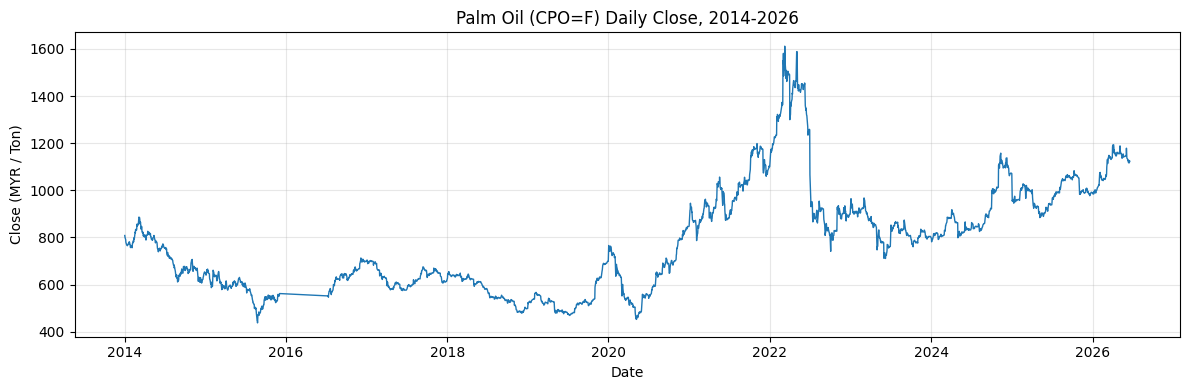

In [4]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(palm['Date'], palm['Close'], linewidth=1.0, color='#1f77b4')
ax.set_title('Palm Oil (CPO=F) Daily Close, 2014-2026')
ax.set_xlabel('Date')
ax.set_ylabel('Close (MYR / Ton)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2. ONI 长表 (NOAA Oceanic Nino Index, 1950-2026)

由 `Day 4/reshape_oni.py` 把宽表 melt 成 (DATE, ONI_Value) 长表。

In [5]:
oni = pd.read_csv(ONI_LONG_CSV)
oni['DATE'] = pd.to_datetime(oni['DATE'])
print('shape:', oni.shape)
print('date span:', oni['DATE'].min().date(), '->', oni['DATE'].max().date())
print('missing per column:')
print(oni.isna().sum())
oni.head()

shape: (916, 2)
date span: 1950-01-01 -> 2026-04-01
missing per column:
DATE         0
ONI_Value    0
dtype: int64


,DATE,ONI_Value
0,1950-01-01,-1.53
1,1950-02-01,-1.34
2,1950-03-01,-1.16
3,1950-04-01,-1.18
4,1950-05-01,-1.07


In [6]:
oni['ONI_Value'].describe()

count    916.000000
mean       0.026146
std        0.830658
min       -2.030000
25%       -0.550000
50%       -0.045000
75%        0.540000
max        2.750000
Name: ONI_Value, dtype: float64

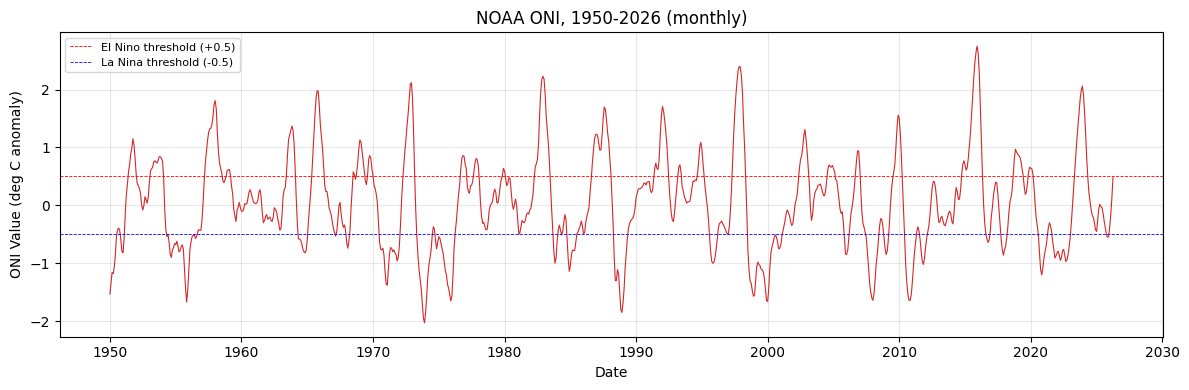

In [7]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(oni['DATE'], oni['ONI_Value'], linewidth=0.8, color='#d62728')
ax.axhline(0.5, color='red', linestyle='--', linewidth=0.6, label='El Nino threshold (+0.5)')
ax.axhline(-0.5, color='blue', linestyle='--', linewidth=0.6, label='La Nina threshold (-0.5)')
ax.set_title('NOAA ONI, 1950-2026 (monthly)')
ax.set_xlabel('Date')
ax.set_ylabel('ONI Value (deg C anomaly)')
ax.grid(alpha=0.3)
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

## 3. 月度合并表：降水 + ONI

由 `Day 4/merge_prcp_oni.py` 输出，作为后续建模的气象侧特征基底。

In [8]:
merged = load_prcp_oni_merged()
print('shape:', merged.shape)
print('span:', merged['DATE'].min(), '->', merged['DATE'].max())
print('missing per column:')
print(merged.isna().sum())
merged.head()

shape: (209, 4)
span: 2006-01 -> 2025-05
missing per column:
DATE             0
PRCP             0
STATION_COUNT    0
ONI_Value        0
dtype: int64


,DATE,PRCP,STATION_COUNT,ONI_Value
0,2006-01,13.87,1,-0.85
1,2006-02,17.59,1,-0.77
2,2006-03,10.00,1,-0.57
3,2006-04,9.16,1,-0.37
4,2006-05,7.93,1,-0.14


In [9]:
merged.describe().T

,count,mean,std,min,25%,50%,75%,max
PRCP,209.0,8.980072,4.429635,0.21,5.925,8.10,10.82,26.35
STATION_COUNT,209.0,1.631579,0.483535,1.00,1.000,2.00,2.00,2.00
ONI_Value,209.0,-0.013254,0.897675,-1.64,-0.620,-0.17,0.49,2.75


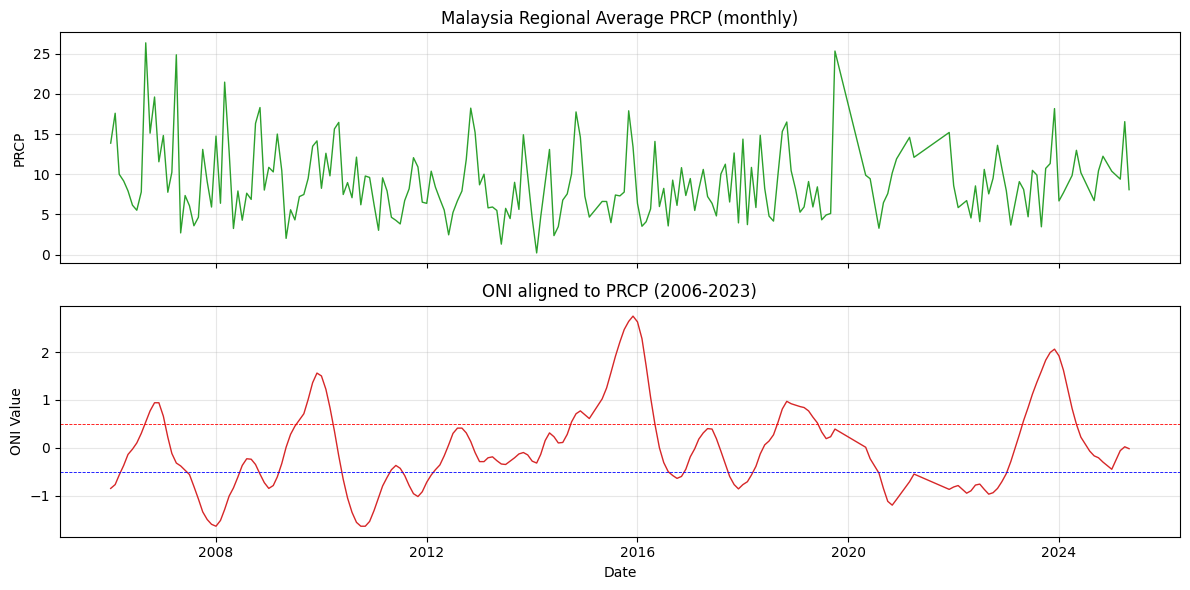

In [10]:
merged_dt = merged.copy()
merged_dt['DATE'] = pd.to_datetime(merged_dt['DATE'])

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(merged_dt['DATE'], merged_dt['PRCP'], color='#2ca02c', linewidth=1.0)
axes[0].set_title('Malaysia Regional Average PRCP (monthly)')
axes[0].set_ylabel('PRCP')
axes[0].grid(alpha=0.3)

axes[1].plot(merged_dt['DATE'], merged_dt['ONI_Value'], color='#d62728', linewidth=1.0)
axes[1].axhline(0.5, color='red', linestyle='--', linewidth=0.6)
axes[1].axhline(-0.5, color='blue', linestyle='--', linewidth=0.6)
axes[1].set_title('ONI aligned to PRCP (2006-2023)')
axes[1].set_ylabel('ONI Value')
axes[1].set_xlabel('Date')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. 小结 (Sanity Check)

- 棕榈油 (Palm Oil)：**2986 行**，2014-01-02 至 2026-06-18，约 12.5 年；Close 缺失 0
- ONI 长表：1950-2026，每月 1 行（约 920 行），无缺失
- 降水+ONI 合并表：209 行月度，2006-2023，无缺失

**已满足 Day 6 验收线**：能从头跑到尾无报错；含棕榈油 + ONI + 降水的描述性统计与肉眼可检的走势图。

**下一步 (W2D2 起)**：基于合并表 + 棕榈油月度对齐，构造滞后特征 (ONI_lag_3/6/9/12, PRCP_lag_3/6) 与价格收益率 / 波动率，生成 `features_palm.csv` 作为建模输入矩阵。